In [26]:
import tensorflow as tf

train_dir = r'C:\Users\HP\Downloads\train_images\train_data'
test_dir = r'C:\Users\HP\Downloads\test_images\test_data'

# Load training images as a tf.data.Dataset
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),    # Resize images on the fly
    batch_size=32,
    label_mode='categorical'  # or 'int' if you want integer labels
)

# Load test images as a tf.data.Dataset
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)


Found 39990 files belonging to 5 classes.
Found 10005 files belonging to 5 classes.


In [27]:
for images, labels in train_dataset.take(1):
    print(images.shape)  # (batch_size, 224, 224, 3)
    print(labels.shape)  # (batch_size, 5)


(32, 224, 224, 3)
(32, 5)


In [28]:
import pandas as pd

# Path to your metadata CSV file
metadata_path = r'C:\Users\HP\Downloads\output.csv'

# Load metadata into a DataFrame
metadata_df = pd.read_csv(metadata_path)

# Preview the metadata
print(metadata_df.head())
print(metadata_df.columns)


                 photo_id             business_id  \
0  zsvj7vloL4L5jhYyPIuVwg  Nk-SJhPlDBkAZvfsADtccA   
1  HCUdRJHHm_e0OCTlZetGLg  yVZtL5MmrpiivyCIrVkGgA   
2  vkr8T0scuJmGVvN2HJelEA  _ab50qdWOk0DdB6XOrBitw   
3  pve7D6NUrafHW3EAORubyw  SZU9c8V2GuREDN5KgyHFJw   
4  H52Er-uBg6rNrHcReWTD2w  Gzur0f0XMkrVxIwYJvOt2g   

                                             caption    label  
0  Nice rock artwork everywhere and craploads of ...   inside  
1                                                NaN  outside  
2                                     oyster shooter    drink  
3                                      Shrimp scampi     food  
4                                                NaN     food  
Index(['photo_id', 'business_id', 'caption', 'label'], dtype='object')


In [30]:
from sklearn.preprocessing import LabelEncoder

# Encode the string labels to integer classes
le = LabelEncoder()
metadata_df['label_encoded'] = le.fit_transform(metadata_df['label'])

print("Classes:", le.classes_)
print(metadata_df[['label', 'label_encoded']].head())


Classes: ['drink' 'food' 'inside' 'menu' 'outside']
     label  label_encoded
0   inside              2
1  outside              4
2    drink              0
3     food              1
4     food              1


In [31]:
# Optional: encode business_id as one-hot or integer
metadata_df['business_id_encoded'] = LabelEncoder().fit_transform(metadata_df['business_id'])

# Example: if you want to use it as a feature
metadata_features = metadata_df[['business_id_encoded']].values

print(metadata_features[:5])


[[14122]
 [35817]
 [21547]
 [16843]
 [10317]]


In [33]:
metadata_df = metadata_df.drop_duplicates(subset='photo_id')


In [34]:
metadata_dict = metadata_df.set_index('photo_id').to_dict(orient='index')


In [35]:
duplicates = metadata_df[metadata_df.duplicated(subset='photo_id', keep=False)]
print(duplicates)


Empty DataFrame
Columns: [photo_id, business_id, caption, label, label_encoded, business_id_encoded]
Index: []


In [36]:
import os
import numpy as np
import tensorflow as tf

image_dir = r'C:\Users\HP\Downloads\train_images\train_data'

image_paths = []
labels = []
meta_features = []

class_names = sorted(os.listdir(image_dir))  # class folders

# Map photo_id to metadata row for quick lookup
metadata_dict = metadata_df.set_index('photo_id').to_dict(orient='index')

for class_name in class_names:
    class_folder = os.path.join(image_dir, class_name)
    for img_file in os.listdir(class_folder):
        image_paths.append(os.path.join(class_folder, img_file))
        labels.append(le.transform([class_name])[0])  # map folder name to label integer

        # Extract photo_id from image filename (remove extension)
        photo_id = os.path.splitext(img_file)[0]

        # Find matching metadata row
        if photo_id in metadata_dict:
            row = metadata_dict[photo_id]
            # Extract business_id_encoded as feature
            business_id_encoded = LabelEncoder().fit_transform([row['business_id']])[0]
            meta_features.append([business_id_encoded])
        else:
            # If no metadata, put zero vector or some default
            meta_features.append([0])

labels = np.array(labels)
meta_features = np.array(meta_features)

# Function to load images and preprocess
def load_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [224,224])
    image /= 255.0
    return image

# Build tf.data.Dataset
path_ds = tf.data.Dataset.from_tensor_slices(image_paths)
image_ds = path_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
metadata_ds = tf.data.Dataset.from_tensor_slices(meta_features)
label_ds = tf.data.Dataset.from_tensor_slices(labels)

# Zip into ((image, metadata), label)
full_ds = tf.data.Dataset.zip(((image_ds, metadata_ds), label_ds))

batch_size = 32
full_ds = full_ds.shuffle(len(image_paths)).batch(batch_size).prefetch(tf.data.AUTOTUNE)


In [37]:
from tensorflow.keras import Input, layers, Model
from tensorflow.keras.applications import VGG16

# Image input branch
image_input = Input(shape=(224,224,3), name='image_input')
base_model = VGG16(include_top=False, weights='imagenet', input_tensor=image_input)
base_model.trainable = False
x = layers.GlobalAveragePooling2D()(base_model.output)

# Metadata input branch (business_id encoded is just 1 integer)
metadata_input = Input(shape=(1,), name='metadata_input')
m = layers.Dense(8, activation='relu')(metadata_input)  # small dense layer for metadata

# Concatenate
combined = layers.concatenate([x, m])
z = layers.Dense(64, activation='relu')(combined)
z = layers.Dropout(0.5)(z)
output = layers.Dense(len(class_names), activation='softmax')(z)

model = Model(inputs=[image_input, metadata_input], outputs=output)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1 (Conv2D)         │ (None, 224, 224, 64)      │           1,792 │ image_input[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2 (Conv2D)         │ (None, 224, 224, 64)      │          36,928 │ block1_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_pool (MaxPooling2D)    │ (None, 112, 112, 64)      │               0 │ block1_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_conv1 (Conv2D)         │ (None, 112, 112, 128)     │          73,856 │ block1_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_conv2 (Conv2D)         │ (None, 112, 112, 128)     │         147,584 │ block2_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_pool (MaxPooling2D)    │ (None, 56, 56, 128)       │               0 │ block2_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_conv1 (Conv2D)         │ (None, 56, 56, 256)       │         295,168 │ block2_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_conv2 (Conv2D)         │ (None, 56, 56, 256)       │         590,080 │ block3_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_conv3 (Conv2D)         │ (None, 56, 56, 256)       │         590,080 │ block3_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_pool (MaxPooling2D)    │ (None, 28, 28, 256)       │               0 │ block3_conv3[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_conv1 (Conv2D)         │ (None, 28, 28, 512)       │       1,180,160 │ block3_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_conv2 (Conv2D)         │ (None, 28, 28, 512)       │       2,359,808 │ block4_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_conv3 (Conv2D)         │ (None, 28, 28, 512)       │       2,359,808 │ block4_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_pool (MaxPooling2D)    │ (None, 14, 14, 512)       │               0 │ block4_conv3[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block5_conv1 (Conv2D)         │ (None, 14, 14, 512)       │       2,359,808 │ block4_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block5_conv2 (Conv2D)         │ (None, 14, 14, 512)       │       2,359,808 │ block5_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 14,748,373 (56.26 MB)

 Trainable params: 33,685 (131.58 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [38]:
from tensorflow.keras import Input, layers, Model
from tensorflow.keras.applications import VGG16

# Image input branch
image_input = Input(shape=(224,224,3), name='image_input')
base_model = VGG16(include_top=False, weights='imagenet', input_tensor=image_input)
base_model.trainable = False
x = layers.GlobalAveragePooling2D()(base_model.output)

# Metadata input branch (business_id encoded is just 1 integer)
metadata_input = Input(shape=(1,), name='metadata_input')
m = layers.Dense(8, activation='relu')(metadata_input)  # small dense layer for metadata

# Concatenate
combined = layers.concatenate([x, m])
z = layers.Dense(64, activation='relu')(combined)
z = layers.Dropout(0.5)(z)
output = layers.Dense(len(class_names), activation='softmax')(z)

model = Model(inputs=[image_input, metadata_input], outputs=output)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1 (Conv2D)         │ (None, 224, 224, 64)      │           1,792 │ image_input[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2 (Conv2D)         │ (None, 224, 224, 64)      │          36,928 │ block1_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_pool (MaxPooling2D)    │ (None, 112, 112, 64)      │               0 │ block1_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_conv1 (Conv2D)         │ (None, 112, 112, 128)     │          73,856 │ block1_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_conv2 (Conv2D)         │ (None, 112, 112, 128)     │         147,584 │ block2_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_pool (MaxPooling2D)    │ (None, 56, 56, 128)       │               0 │ block2_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_conv1 (Conv2D)         │ (None, 56, 56, 256)       │         295,168 │ block2_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_conv2 (Conv2D)         │ (None, 56, 56, 256)       │         590,080 │ block3_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_conv3 (Conv2D)         │ (None, 56, 56, 256)       │         590,080 │ block3_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_pool (MaxPooling2D)    │ (None, 28, 28, 256)       │               0 │ block3_conv3[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_conv1 (Conv2D)         │ (None, 28, 28, 512)       │       1,180,160 │ block3_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_conv2 (Conv2D)         │ (None, 28, 28, 512)       │       2,359,808 │ block4_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_conv3 (Conv2D)         │ (None, 28, 28, 512)       │       2,359,808 │ block4_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_pool (MaxPooling2D)    │ (None, 14, 14, 512)       │               0 │ block4_conv3[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block5_conv1 (Conv2D)         │ (None, 14, 14, 512)       │       2,359,808 │ block4_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block5_conv2 (Conv2D)         │ (None, 14, 14, 512)       │       2,359,808 │ block5_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 14,748,373 (56.26 MB)

 Trainable params: 33,685 (131.58 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [39]:
history = model.fit(full_ds, epochs=10)


Epoch 1/10


C:\Users\HP\anaconda3\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['image_input', 'metadata_input']. Received: the structure of inputs=('*', '*')
  warnings.warn(


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5789s 5s/step - accuracy: 0.6089 - loss: 1.0114
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7036s 5s/step - accuracy: 0.7832 - loss: 0.6119
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5941s 5s/step - accuracy: 0.8053 - loss: 0.5489
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5936s 5s/step - accuracy: 0.8183 - loss: 0.5122
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5685s 4s/step - accuracy: 0.8237 - loss: 0.4992
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6055s 5s/step - accuracy: 0.8252 - loss: 0.4865
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5968s 5s/step - accuracy: 0.8351 - loss: 0.4640
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5484s 4s/step - accuracy: 0.8356 - loss: 0.4667
Epoch 9/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5539s 4s/step - accuracy: 0.8403 - loss: 0.4443
Epoch 10/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5536s 4s/step - accuracy: 0.8382 - loss: 0.4524


In [ ]:
# Save in HDF5 format
model.save("multimodal_vgg16_model.h5")


In [ ]:
from google.colab import files

# Download the model file
files.download("multimodal_vgg16_model.h5")


In [ ]:
# Save to specific directory on your PC
model.save("C:/Users/HP/Downloads/multimodal_vgg16_model.h5")


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("C:/Users/HP/Downloads/multimodal_vgg16_model.h5")


In [ ]:
# Save the entire model (architecture + weights + optimizer state)
model.save('multimodal_vgg16_model.h5')


In [ ]:
model.save('multimodal_vgg16_model')  # Creates a folder with the model


In [ ]:
from tensorflow.keras.models import load_model

# For .h5 format
model = load_model('multimodal_vgg16_model.h5')

# OR for SavedModel format
model = load_model('multimodal_vgg16_model')


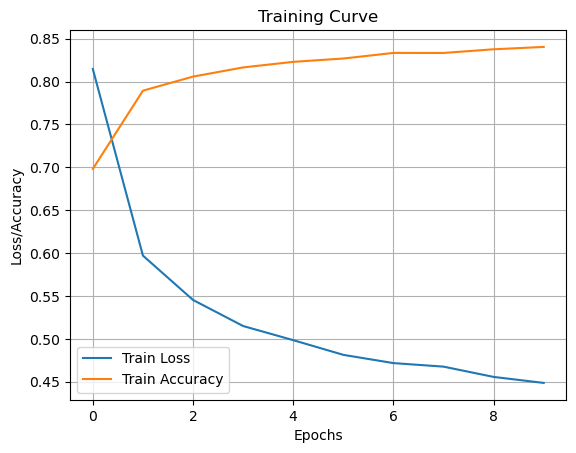

In [40]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.title('Training Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss/Accuracy')
plt.legend()
plt.grid()
plt.show()
